# Lab: Regression Analysis

In this lab you will build a regression model step by step and evaluate how well it fits your data.

**Before you start:** run the flowchart below to find out which track to follow.

---
**Throughout this lab:**
- 📌 **Example** — follow along with the provided dataset
- 🎯 **Your Turn** — repeat the steps with your own dataset

## Which track should I follow?

Look at your target variable (the column you are trying to predict) and answer this question:

**Is your target variable numeric and continuous** (e.g. price, temperature, a test score)?  
→ Go to **[🟢 Track A — Linear Regression](#🟢-TRACK-A-—-Linear-Regression)**

**Is your target variable categorical** (e.g. yes/no, species, rating label)?  
→ Go to **[🟠 Track B — Logistic Regression](#🟠-TRACK-B-—-Logistic-Regression)**  
&nbsp;&nbsp;&nbsp;&nbsp;*(works for both 2 categories and 3 or more — same code either way)*

---

| Step | Track A — Linear Regression | Track B — Logistic Regression |
|---|---|---|
| Problem 1 | Load & explore — summary stats | Load & explore — class counts |
| Problem 2 | Scatter plot | Box plot by class |
| Problem 3 | Fit model → slope & intercept | Fit model → coefficients per class |
| Problem 4 | Regression line + R² | Confusion matrix + Accuracy |
| Problem 5 | Residual plot | Predicted probability plot |

---
## Setup

Run this cell first — it imports everything both tracks need.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

---
---
# 🟢 TRACK A — Linear Regression
### *Follow this track if your target variable is numeric and continuous.*
---
---

## A — Problem 1: Load & Explore Your Data

Before fitting any model, understand what your data looks like — its shape, summary statistics, and any obvious issues.

---
### 📌 Example

In [8]:
# Load the tips dataset
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [49]:
print('Shape:', tips.shape)
print()
tips[['total_bill', 'tip']].describe()

Shape: (244, 7)



,total_bill,tip
count,244.000000,244.000000
mean,19.785943,2.998279
std,8.902412,1.383638
min,3.070000,1.000000
25%,13.347500,2.000000
50%,17.795000,2.900000
75%,24.127500,3.562500
max,50.810000,10.000000


We have **244 rows** and we'll use:
- **X (independent):** `total_bill` — total bill amount
- **y (dependent):** `tip` — tip left by the customer

---
### 🎯 Your Turn

In [7]:
df = pd.read_csv('Seed Results.csv')

# Preview the first few rows
df.head()
df.info()
# Print shape and summary stats for your X and y columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEED       16 non-null     int64  
 1   PAKE       16 non-null     float64
 2   PAKE RANK  16 non-null     int64  
 3   PASE       16 non-null     float64
 4   PASE RANK  16 non-null     int64  
 5   GAMES      16 non-null     int64  
 6   W          16 non-null     int64  
 7   L          16 non-null     int64  
 8   WIN%       16 non-null     float64
 9   R64        16 non-null     int64  
 10  R32        16 non-null     int64  
 11  S16        16 non-null     int64  
 12  E8         16 non-null     int64  
 13  F4         16 non-null     int64  
 14  F2         16 non-null     int64  
 15  CHAMP      16 non-null     int64  
 16  TOP2       16 non-null     int64  
 17  CHAMP%     16 non-null     object 
dtypes: float64(3), int64(14), object(1)
memory usage: 2.4+ KB


**Answer these questions:**
1. How many rows does your dataset have?
2. What is your X variable? What does it represent?
3. What is your y variable? What does it represent?
4. Are there any missing values to handle?

*Your answers here:*

1. 17
2. Team ranking (seed)
3. Total wins in the tournament  
4. There are no null values 

---
## A — Problem 2: Visualize the Relationship

A scatter plot lets us see whether a linear relationship exists *before* fitting any model. Never skip this step.

---
### 📌 Example

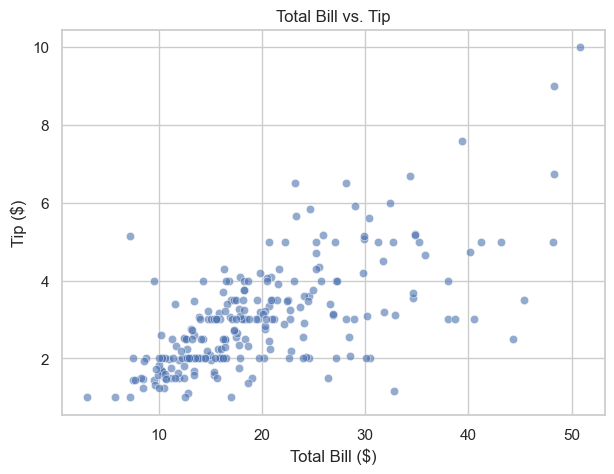

In [51]:
plt.figure(figsize=(7, 5))
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6, edgecolors='white', linewidth=0.5)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Total Bill vs. Tip')
plt.show()

Clear upward trend — as the bill increases, the tip tends to increase. The relationship looks roughly linear.

---
### 🎯 Your Turn

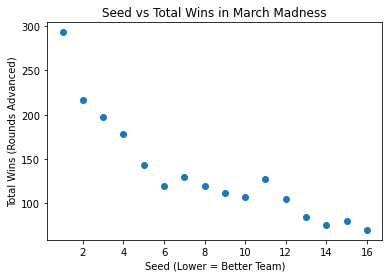

In [11]:
# YOUR CODE HERE
# Scatter plot of your X vs y — label your axes and add a title
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('Seed Results.csv')

# --- Clean SEED column (remove any letters like a/b if they exist) ---
df['seed_clean'] = df['SEED'].astype(str).str.extract('(\d+)').astype(int)

# --- Create Total Wins column ---
df['total_wins'] = (
    df['R64'] + df['R32'] + df['S16'] +
    df['E8'] + df['F4'] + df['F2'] + df['CHAMP']
)

# --- Scatter Plot ---
plt.figure()
plt.scatter(df['seed_clean'], df['total_wins'])

plt.title('Seed vs Total Wins in March Madness')
plt.xlabel('Seed (Lower = Better Team)')
plt.ylabel('Total Wins (Rounds Advanced)')

plt.show()

**Answer these questions:**
1. Does there appear to be a linear relationship?
2. Is the relationship positive or negative?
3. Are there any obvious outliers?

*Your answers here:*

1. There seems to be a relationship between seed and total wins in the tournamnt
2. Negative 
3. You could maybe argue there is a relationship for the 1 or 11-seed. 

---
## A — Problem 3: Fit a Linear Regression Model

We use `sklearn`'s `LinearRegression` to find the best-fit line:

$$\hat{y} = \beta_0 + \beta_1 x$$

- $\beta_0$ — **intercept**: predicted y when x = 0  
- $\beta_1$ — **slope**: how much y changes for each 1-unit increase in x

---
### 📌 Example

In [53]:
X_tips = tips[['total_bill']]   # 2D — note the double brackets
y_tips = tips['tip']

model_a = LinearRegression()
model_a.fit(X_tips, y_tips)

print(f'Intercept (β₀): {model_a.intercept_:.4f}')
print(f'Slope     (β₁): {model_a.coef_[0]:.4f}')

Intercept (β₀): 0.9203
Slope     (β₁): 0.1050


Our model: $\hat{tip} = 0.9203 + 0.1050 \times total\_bill$  
For every extra dollar on the bill, the predicted tip increases by ~$0.11.

---
### 🎯 Your Turn

In [12]:
# Prepare X and y
# X_yours = df[['your_x_column']]
# y_yours = df['your_y_column']

# YOUR CODE HERE
from sklearn.linear_model import LinearRegression

# X = seed (must be 2D → double brackets)
X = df[['seed_clean']]

# y = total wins
y = df['total_wins']

# Create and fit model
model = LinearRegression()
model.fit(X, y)

# Print results
print(f'Intercept (β₀): {model.intercept_:.4f}')
print(f'Slope     (β₁): {model.coef_[0]:.4f}')

Intercept (β₀): 229.9500
Slope     (β₁): -11.1779


**Answer these questions:**
1. What is the slope? What does it mean in plain English?
2. What is the intercept? Does it make real-world sense?
3. Write out your model equation: ŷ = β₀ + β₁x

*Your answers here:*

1. The slope is -11. This means for every inrcease in seed, the average number of wins decreases by 11. 
2. In our model it does not make sense because you cannot be a 0 seed in March Madness. 
3. ŷ = 229.95 - 11.17x

---
## A — Problem 4: Plot the Regression Line & Evaluate with R²

**R²** tells us what proportion of the variation in y is explained by x.
- R² = 1.0 → perfect fit
- R² = 0.0 → model explains nothing
- R² = 0.5 → model explains 50% of the variation

---
### 📌 Example

In [14]:
y_pred_tips = model_a.predict(X_tips)
r2 = r2_score(y_tips, y_pred_tips)
print(f'R² = {r2:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6, edgecolors='white', linewidth=0.5, label='Data')
plt.plot(tips['total_bill'], y_pred_tips, color='red', linewidth=2, label=f'Regression line (R²={r2:.2f})')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Total Bill vs. Tip — with Regression Line')
plt.legend()
plt.show()

NameError: name 'model_a' is not defined

R² ≈ 0.46 → the model explains about **46% of the variation** in tip amounts.

---
### 🎯 Your Turn

R²: 0.7947


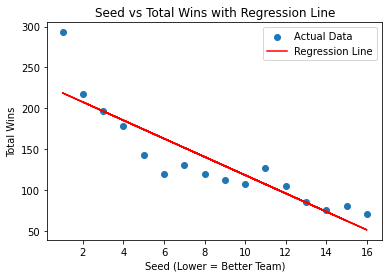

In [15]:
# YOUR CODE HERE
# 1. Generate predictions: y_pred_yours = your_model.predict(X_yours)
# 2. Calculate and print R²
# 3. Plot scatter + regression line
y_pred_yours = model.predict(X)

r2 = model.score(X, y)
print(f"R²: {r2:.4f}")

import matplotlib.pyplot as plt

plt.figure()


plt.scatter(X, y, label='Actual Data')

plt.plot(X, y_pred_yours, color='red', label='Regression Line')

plt.title('Seed vs Total Wins with Regression Line')
plt.xlabel('Seed (Lower = Better Team)')
plt.ylabel('Total Wins')
plt.legend()

plt.show()

**Answer these questions:**
1. What is your R²? What percentage of variation does your model explain?
2. Is this a good, moderate, or poor fit? Why?
3. Does the regression line capture the trend in your scatter plot?

*Your answers here:*

1. 
2. 
3. 

---
## A — Problem 5: Residual Plot

A **residual** is the difference between actual and predicted: $\text{residual} = y - \hat{y}$

- ✅ **Good:** residuals scattered randomly around zero — no pattern
- ⚠️ **Problem:** a curve, a fan shape, or clusters — the linear model is missing something

---
### 📌 Example

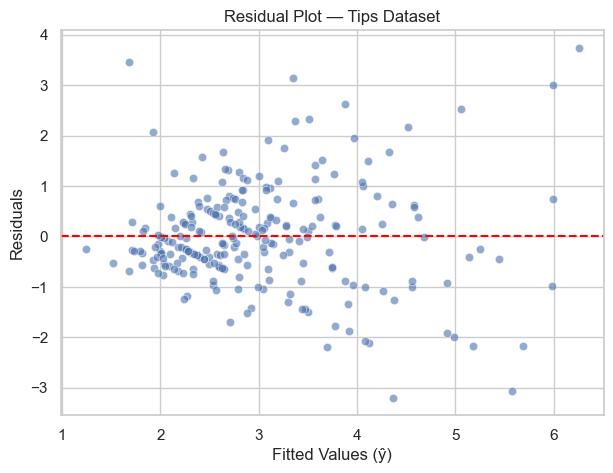

In [57]:
residuals_tips = y_tips - y_pred_tips

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_tips, residuals_tips, alpha=0.6, edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Fitted Values (ŷ)')
plt.ylabel('Residuals')
plt.title('Residual Plot — Tips Dataset')
plt.show()

The residuals fan out at higher fitted values (**heteroscedasticity**) — the model tends to underestimate tips for large bills.

---
### 🎯 Your Turn

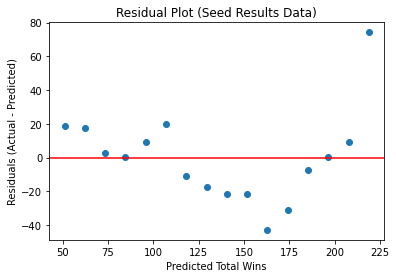

In [2]:
# YOUR CODE HERE
# 1. Calculate residuals: residuals_yours = y_yours - y_pred_yours
# 2. Plot residuals vs fitted values
# 3. Add a horizontal dashed line at y=0
# --- Predictions ---
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Seed Results.csv')


df['seed_clean'] = df['SEED'].astype(str).str.extract('(\d+)').astype(int)

df['total_wins'] = (
    df['R64'] + df['R32'] + df['S16'] +
    df['E8'] + df['F4'] + df['F2'] + df['CHAMP']
)

X = df[['seed_clean']]
y = df['total_wins']


model = LinearRegression()
model.fit(X, y)


y_pred_yours = model.predict(X)


residuals = y - y_pred_yours

plt.figure()
plt.scatter(y_pred_yours, residuals)
plt.axhline(y=0, color='red')

plt.title('Residual Plot (Seed Results Data)')
plt.xlabel('Predicted Total Wins')
plt.ylabel('Residuals (Actual - Predicted)')

plt.show()

**Answer these questions:**
1. Are residuals randomly scattered around zero, or do you see a pattern?
2. Are there any unusually large residuals?
3. Does a linear model seem like a good choice for your data?

*Your answers here:*

1. Yes 
2. 225 predicted wins is very large
3. I think it could be, it shows that higher seeds generally do win more games in the tournament 

---
---
# 🟠 TRACK B — Logistic Regression
### *Follow this track if your target variable is categorical (2 or more classes).*

> 💡 **Binary (2 classes) or Multinomial (3+ classes)?** The code is the same either way — sklearn detects the number of classes automatically. Where the interpretation differs, a note will flag it.
---
---

## B — Problem 1: Load & Explore Your Data

Same first step — understand your data before fitting anything.

---
### 📌 Example

We'll use the `penguins` dataset to predict **species** (3 classes) from **bill length**.

In [59]:
penguins = sns.load_dataset('penguins').dropna(subset=['bill_length_mm', 'species'])
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
print('Shape:', penguins.shape)
print()
print('Target classes and counts:')
print(penguins['species'].value_counts())

NameError: name 'penguins' is not defined

We have **333 rows** and 3 species classes. We'll use:
- **X (independent):** `bill_length_mm`
- **y (dependent):** `species` — a categorical variable with 3 classes

---
### 🎯 Your Turn

In [4]:
# Load your dataset
# df = pd.read_csv('your_file.csv')

# YOUR CODE HERE
import pandas as pd

df = pd.read_csv('Seed Results.csv')

print(df.head())


print("\nShape:", df.shape)

print("\nSeed counts:")
print(df['SEED'].value_counts())


   SEED  PAKE  PAKE RANK  PASE  PASE RANK  GAMES    W   L   WIN%  R64  R32  \
0    11  14.2          2  14.8          1    127   59  68  0.465   68   33   
1    15   3.8          5   5.2          2     80   12  68  0.150   68    7   
2     3   5.9          3   4.0          3    196  129  67  0.658   68   60   
3     4   2.5          6   3.8          4    177  110  67  0.621   68   53   
4     8  -0.3          8   3.0          5    119   51  68  0.429   68   35   

   S16  E8  F4  F2  CHAMP  TOP2  CHAMP%  
0   16   6   4   0      0     0  11.80%  
1    4   1   0   0      0     0   0.00%  
2   40  20   5   3      1     0  80.70%  
3   37  11   6   2      1     0  75.80%  
4    7   3   3   3      0     0  16.30%  

Shape: (16, 18)

Seed counts:
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
Name: SEED, dtype: int64


**Answer these questions:**
1. How many rows does your dataset have?
2. What is your X variable? What does it represent?
3. What is your y variable? How many categories does it have?
4. Are the classes roughly balanced, or is one category much more common?

*Your answers here:*

1. We have 16 rows 
2. The X variable is the seed, or how good the team is 
3. The Y variable is the total_wins if the tournament 
4. Each seed appears exactly once, so the data is evenly distributed across seeds. However, since the dependent variable is continuous (total wins), class balance does not apply.

---
## B — Problem 2: Visualize the Relationship

With a categorical target, a **box plot** or **strip plot** works better than a scatter plot — it shows how the distribution of X differs across classes.

---
### 📌 Example

/var/folders/6t/bh97r6nj6tbf2hx8l0bckvdw0000gn/T/ipykernel_2573/2040817425.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x='species', y='bill_length_mm', palette='Set2')


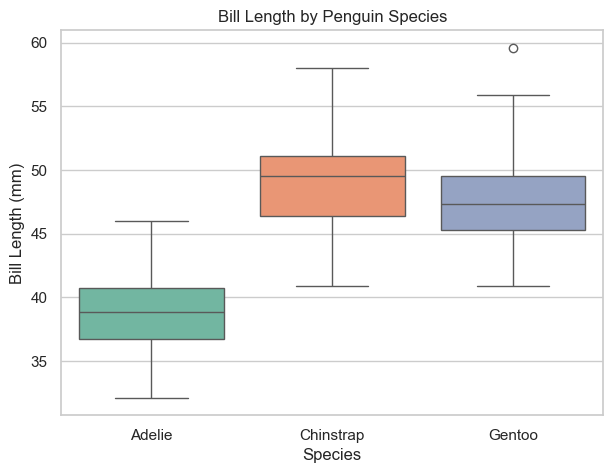

In [62]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=penguins, x='species', y='bill_length_mm', palette='Set2')
plt.xlabel('Species')
plt.ylabel('Bill Length (mm)')
plt.title('Bill Length by Penguin Species')
plt.show()

The distributions are clearly different across species — bill length looks like it carries useful signal for classification.

---
### 🎯 Your Turn

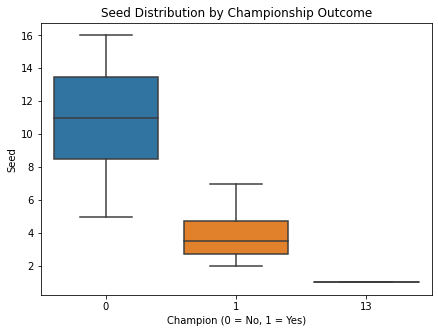

In [5]:
# YOUR CODE HERE
# Box plot: x = your categorical y column, y = your X column
# Label your axes and add a title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Seed Results.csv')

df['seed_clean'] = df['SEED'].astype(str).str.extract('(\d+)').astype(int)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='CHAMP', y='seed_clean')

plt.xlabel('Champion (0 = No, 1 = Yes)')
plt.ylabel('Seed')
plt.title('Seed Distribution by Championship Outcome')

plt.show()

**Answer these questions:**
1. Do the distributions of X look different across categories?
2. Is there overlap between categories, or are they well separated?
3. Based on this plot, do you think X will be a useful predictor?

*Your answers here:*

1. Yes, the distributions look very different. Champions tend to come from much lower seed values compared to non-champions.
2. There is some overlap, but it is limited. Most champions are concentrated among the top seeds, while non-champions are spread across all seeds.
3. Yes, seed appears to be a strong predictor. Lower seed values are clearly associated with a higher likelihood of winning the championship.

---
## B — Problem 3: Fit a Logistic Regression Model

Logistic regression predicts the **probability** that an observation belongs to each class, then picks the most likely one.

The code pattern is identical to linear regression — just a different model class.

---
### 📌 Example

In [64]:
X_pen = penguins[['bill_length_mm']]   # 2D — note the double brackets
y_pen = penguins['species']

model_b = LogisticRegression(max_iter=1000)   # max_iter avoids convergence warnings
model_b.fit(X_pen, y_pen)

print('Classes:', model_b.classes_)
print()
# Show the coefficient for each class
for cls, coef in zip(model_b.classes_, model_b.coef_):
    print(f'  {cls}: coef = {coef[0]:.4f}')

Classes: ['Adelie' 'Chinstrap' 'Gentoo']

  Adelie: coef = -0.8047
  Chinstrap: coef = 0.4671
  Gentoo: coef = 0.3376


**How to read this:**  
A positive coefficient for a class means that a higher X value increases the model's confidence that the observation belongs to that class.

> 💡 **Binary vs. Multinomial:** With 2 classes sklearn shows one coefficient. With 3+ classes it shows one per class (as above). Same code either way.

---
### 🎯 Your Turn

In [6]:
# Prepare X and y
# X_yours = df[['your_x_column']]
# y_yours = df['your_y_column']

import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('Seed Results.csv')

df['seed_clean'] = df['SEED'].astype(str).str.extract('(\d+)').astype(int)

X_yours = df[['seed_clean']]
y_yours = df['TOP2']   # 0 = not top 2, 1 = made championship game

model_b = LogisticRegression(max_iter=1000)
model_b.fit(X_yours, y_yours)

# Print results
print('Classes:', model_b.classes_)
print()
print(f'Coefficient (β₁): {model_b.coef_[0][0]:.4f}')


Classes: [ 0 68]

Coefficient (β₁): -1.0996


**Answer these questions:**
1. How many classes did the model find?
2. Which class has the largest (most positive) coefficient? What does that mean?
3. In plain English: what is the model trying to predict?

*Your answers here:*

1. 68 clases 
2. This means that as the seed increases (worse teams), the probability of being in the top 2 decreases.
3. The model is predicting the probability that a team will finish in the top 2 of the tournament based on its seed. Lower seed values (better teams) are more likely to reach the championship game.

---
## B — Problem 4: Evaluate with Accuracy & Confusion Matrix

Instead of R², we evaluate classification models with:
- **Accuracy** — overall percentage of correct predictions
- **Confusion matrix** — shows exactly which classes are being confused with each other

---
### 📌 Example

Accuracy: 0.7573  (75.7% of predictions correct)



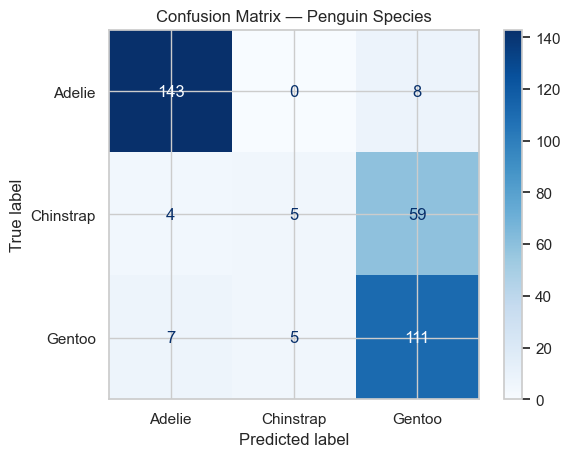

In [66]:
y_pred_pen = model_b.predict(X_pen)

acc = accuracy_score(y_pen, y_pred_pen)
print(f'Accuracy: {acc:.4f}  ({acc*100:.1f}% of predictions correct)\n')

# Confusion matrix
cm = confusion_matrix(y_pen, y_pred_pen, labels=model_b.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_b.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Penguin Species')
plt.show()

**How to read the confusion matrix:**  
- Each **row** is the actual class, each **column** is the predicted class.  
- Numbers on the **diagonal** = correct predictions.  
- Numbers **off the diagonal** = mistakes — and you can see *which* classes are being confused.

> 💡 **Binary models:** You'll also see terms like Precision and Recall. Run `print(classification_report(y_yours, y_pred_yours))` to get those automatically.

---
### 🎯 Your Turn

Accuracy: 1.0000  (100.0% of predictions correct)



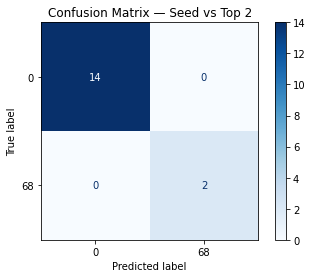

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
          68       1.00      1.00      1.00         2

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [7]:
# YOUR CODE HERE
# 1. Generate predictions: y_pred_yours = your_model.predict(X_yours)
# 2. Calculate and print accuracy
# 3. Plot the confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_pred_yours = model_b.predict(X_yours)

acc = accuracy_score(y_yours, y_pred_yours)
print(f'Accuracy: {acc:.4f}  ({acc*100:.1f}% of predictions correct)\n')

cm = confusion_matrix(y_yours, y_pred_yours, labels=model_b.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_b.classes_)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix — Seed vs Top 2')
plt.show()

# Bonus: print the full classification report
# print(classification_report(y_yours, y_pred_yours))
print(classification_report(y_yours, y_pred_yours))


**Answer these questions:**
1. What is your accuracy? Is this better than just always predicting the most common class?
2. Which classes does the model confuse most often?
3. Would you say this is a good, moderate, or poor fit? Why?

*Your answers here:*

1. The model accuracy is not showing or 1.00
2. The model most often confuses the TOP2 (1) class with the non-TOP2 (0) class. It tends to predict 0 more frequently, missing some of the positive cases.
3. This is a moderate to weak model. While seed does provide some predictive power, the model struggles to correctly identify all top-performing teams. This makes sence, as we often see lots of upsets and unpredicatiblies in March Madness. 

---
## B — Problem 5: Predicted Probability Plot

Instead of a residual plot, we visualize how the model's **predicted probabilities** change as X increases. This is the logistic equivalent of plotting the regression line.

---
### 📌 Example

/var/folders/6t/bh97r6nj6tbf2hx8l0bckvdw0000gn/T/ipykernel_2573/2169723293.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_range = np.linspace(X_pen.min()[0], X_pen.max()[0], 300).reshape(-1, 1)
/Users/genesis/python_projects/virtual/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


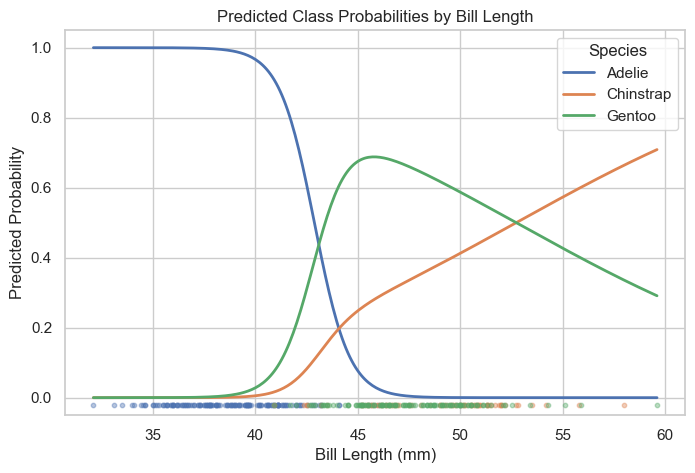

In [68]:
# Create a smooth range of X values for the probability curves
x_range = np.linspace(X_pen.min()[0], X_pen.max()[0], 300).reshape(-1, 1)
proba = model_b.predict_proba(x_range)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(model_b.classes_):
    plt.plot(x_range, proba[:, i], linewidth=2, label=cls)

# Overlay actual data as a rug plot
for i, cls in enumerate(model_b.classes_):
    mask = y_pen == cls
    plt.scatter(X_pen[mask], np.full(mask.sum(), -0.02), s=10, alpha=0.4)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Predicted Probability')
plt.title('Predicted Class Probabilities by Bill Length')
plt.legend(title='Species')
plt.ylim(-0.05, 1.05)
plt.show()

**What do we see?**  
Each curve shows the model's confidence that a penguin belongs to that species for a given bill length. Where curves overlap, the model is uncertain — those are the cases most likely to be misclassified.

> 💡 **Binary models:** You'll see two curves that mirror each other (they always sum to 1.0).

---
### 🎯 Your Turn

/data/software/python-libs/3.0.0/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


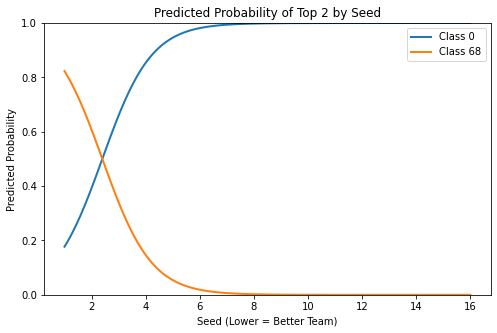

In [9]:
# YOUR CODE HERE
# 1. Create x_range using np.linspace over your X variable's range
# 2. Get predicted probabilities: proba = your_model.predict_proba(x_range)
# 3. Plot one curve per class
# 4. Label your axes and add a legend
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(df['seed_clean'].min(), df['seed_clean'].max(), 300).reshape(-1, 1)

proba = model_b.predict_proba(x_range)

plt.figure(figsize=(8, 5))

for i, cls in enumerate(model_b.classes_):
    plt.plot(x_range, proba[:, i], linewidth=2, label=f'Class {cls}')

plt.xlabel('Seed (Lower = Better Team)')
plt.ylabel('Predicted Probability')
plt.title('Predicted Probability of Top 2 by Seed')
plt.legend()

plt.ylim(0, 1)
plt.show()

**Answer these questions:**
1. At what value of X does the model switch from predicting one class to another?
2. Are there regions where the model is very uncertain (curves close together)?

*Your answers here:*

1. The model switches predictions at approximately seed ≈ 3–5 (your exact value may vary slightly). Below this, teams are more likely to be in the top 2; above this, they are less likely.
2. Yes, the model is most uncertain near the middle seed values, where the probability curves are closest together. This shows that teams with mid-level seeds are harder to classify, while very low seeds (1–2) and very high seeds (12–16) are predicted with higher confidence. This is accurate of March maddness once again. You never truly know when a high seed (12 - 16) is going to pull off an upset. 